# <center>Recurrent Neural Networks</center>
## <center>Inclass Project 3 - MA4144</center>

This project contains 10 tasks/questions to be completed, some require written answers. Open a markdown cell below the respective question that require written answers and provide (type) your answers. Questions that required written answers are given in blue fonts. Almost all written questions are open ended, they do not have a correct or wrong answer. You are free to give your opinions, but please provide related answers within the context.

After finishing project run the entire notebook once and **save the notebook as a pdf** (File menu -> Save and Export Notebook As -> PDF). You are **required to upload this PDF on moodle**.

***

## Outline of the project

The aim of the project is to build a RNN model to suggest autocompletion of half typed words. You may have seen this in many day today applications; typing an email, a text message etc. For example, suppose you type in the four letter "univ", the application may suggest you to autocomplete it by "university".

![Autocomplete](https://d33v4339jhl8k0.cloudfront.net/docs/assets/5c12e83004286304a71d5b72/images/66d0cb106eb51e63b8f9fbc6/file-gBQe016VYt.gif)

We will train a RNN to suggest possible autocompletes given $3$ - $4$ starting letters. That is if we input a string "univ" hopefully we expect to see an output like "university", "universal" etc.

For this we will use a text file (wordlist.txt) containing 10,000 common English words (you'll find the file on the moodle link). The list of words will be the "**vocabulary**" for our model.

We will use the Python **torch library** to implement our autocomplete model. 

***


Use the below cell to use any include any imports

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import random
from tqdm import tqdm

## Section 1: Preparing the vocabulary

In [2]:
WORD_SIZE = 13

**Q1.** In the following cell provide code to load the text file (each word is in a newline), then extract the words (in lowercase) into a list.

For practical reasons of training the model we will only use words that are longer that $3$ letters and that have a maximum length of WORD_SIZE (this will be a constant we set at the beginning - you can change this and experiment with different WORD_SIZEs). As seen above it is set to $13$.

So out of the extracted list of words filter out those words that match our criteria on word length.

To train our model it is convenient to have words/strings of equal length. We will choose to convert every word to length of WORD_SIZE, by adding underscores to the end of the word if it is initially shorter than WORD_SIZE. For example, we will convert the word "university" (word length 10) into "university___" (wordlength 13). In your code include this conversion as well.

Store the processed WORD_SIZE lengthed strings in a list called vocab.

In [4]:
#TODO

# loading the wordlist.txt file
f = open("./wordlist.txt", "r")

# extracting the words into a list named 'wordlist'
wordlist = f.read().splitlines()

# printing the list
# print("\noriginal word list: ", wordlist)

min_word_size = 4 # minimum word size - only use words that are longer than 3 letters
max_word_size = WORD_SIZE # maximum word size

# new list to store the words that has the length between min_word_size and max_word_size
filtered_wordlist = [] 

for word in wordlist:
    if len(word) >= min_word_size and len(word) <= max_word_size:
        filtered_wordlist.append(word)
        
# printing filtered word list
# print("\nfiltered word list: ", filtered_wordlist) 

# new list to stored the words that has the length equal to WORD_SIZE
vocab = []

for word in filtered_wordlist:
    if len(word) < max_word_size:
        word = word.ljust(max_word_size, '_')
    vocab.append(word)
    
# print("\nvocab list: ", vocab)
    

<font color='blue'>In the above explanation it was mentioned "for practical reasons of training the model we will only use words that are longer that $3$ letters and that have a certain maximum length". In your opinion what could be those practical? Will hit help to build a better model?</font>

<font color='blue'> **Answer:**  
The practical reasons are to ensure consistent input size, simplify model training, and reduce noise from very short words that are less meaningful. Limiting word length ensures efficient processing and helps the model focus on more important words, leading to better performance. Yes, it helps build a more accurate and effective model.
</font>


**Q2** To input words into the model, we will need to convert each letter/character into a number. as we have seen above, the only characters in our list vocab will be the underscore and lowercase english letters. so we will convert these $27$ characters into numbers as follows: underscore -> $0$, 'a' -> $1$, 'b' -> $2$, $\cdots$, 'z' -> $26$. In the following cell,

(i) Implement a method called char_to_num, that takes in a valid character and outputs its numerical assignment.

(ii) Implement a method called num_to_char, that takes in a valid number from $0$ to $26$ and outputs the corresponding character.

(iii) Implement a method called word_to_numlist, that takes in a word from our vocabulary and outputs a (torch) tensor of numbers that corresponds to each character in the word in that order. For example: the word "united_______" will be converted to tensor([21, 14,  9, 20,  5,  4,  0,  0,  0,  0,  0,  0,  0]). You are encouraged to use your char_to_num method for this.

(iv) Implement a method called numlist_to_word, that does the opposite of the above described word_to_numlist, given a tensor of numbers from $0$ to $26$, outputs the corresponding word. You are encouraged to use your  num_to_char method for this.

Note: As mentioned since we are using the torch library we will be using tensors instead of the usual python lists or numpy arrays. Tensors are the list equivalent in torch. Torch models only accept tensors as input and they output tensors.

In [15]:
def char_to_num(char):

    #TODO
    if char == '_':
        num = 0
    else:
        num = ord(char) - 96
        
    # print("char: ", char, "is convert to num: ", num)
    
    return(num)

def num_to_char(num):

    #TODO
    if num == 0:
        char = '_'
    else:
        char = chr(num + 96)
    
    # print("num: ", num, "is convert to char: ", char)
    
    return(char)

def word_to_numlist(word):

    #TODO
    numlist = []
    
    for char in word:
        number = char_to_num(char)
        numlist.append(number)
    
    torch.tensor(numlist)
    # print("word: ", word, "is convert to numlist tensor: ", numlist)
    
    return(numlist)

def numlist_to_word(numlist):

    #TODO
    word = ""
    for num in numlist:
        char = num_to_char(num)
        word = word + char
    
    # print("numlist tensor: ", numlist, "is convert to word: ", word)
    
    return(word)

<font color='blue'>We convert letter into just numbers based on their aphabetical order, I claim that it is a very bad way to encode data such as letters to be fed into learning models, please write your explanation to or against my claim. If you are searching for reasons, the keyword 'categorical data' may be useful. Although the letters in our case are not treated as categorical data, the same reasons as for categorical data is applicable. Even if my claim is valid, at the end it won't matter due to something called "embedding layers" that we will use in our model. What is an embedding layer? What is it's purpose? Explain.</font>

<font color='blue'> **Answer:**   
Your claim is valid. Encoding letters as numbers based on alphabetical order is a poor approach because it introduces false relationships between characters. Similar to categorical data, this method assumes numerical proximity equals similarity, which isn't true for letters (e.g., 'a' and 'b' aren't inherently more related than 'a' and 'z').

However, embedding layers address this issue. An **embedding layer** transforms categorical inputs (like letters) into dense vectors in a learned space, capturing meaningful relationships without relying on numerical order. It provides better, more efficient representations, improving model performance.</font>


## Section 2: Implementing the Autocomplete model

We will implement a RNN model based on LSTM. The [video tutorial](https://www.youtube.com/watch?v=tL5puCeDr-o) will be useful. Our model will be only one hidden layer, but feel free to sophisticate with more layers after the project for your own experiments.

Our model will contain all the training and prediction methods as single package in a class (autocompleteModel) we will define and implement below.

In [16]:
LEARNING_RATE = 0.005

In [17]:
class autocompleteModel(nn.Module):

    #Constructor
    def __init__(self, alphabet_size, embed_dim, hidden_size, num_layers):
        super().__init__()

        #Set the input parameters to self parameters

        #TODO
        self.alphabet_size = alphabet_size
        self.embed_dim = embed_dim
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        #Initialize the layers in the model:
        #1 embedding layer, 1 - LSTM cell (hidden layer), 1 fully connected layer with linear activation

        #TODO
        self.embedding = nn.Embedding(alphabet_size, embed_dim)
        self.lstm = nn.LSTM(embed_dim, hidden_size, num_layers)
        self.fc = nn.Linear(hidden_size, alphabet_size)
        

    #Feedforward
    def forward(self, character, hidden_state, cell_state):

        #Perform feedforward in order
        #1. Embed the input (one charcter represented by a number)
        #2. Feed the embedded output to the LSTM cell
        #3. Feed the LSTM output to the fully connected layer to obtain the output
        #4. return the output, and both the hidden state and cell state from the LSTM cell output

        #TODO
        embedded = self.embedding(character) 
        output, (hidden_state, cell_state) = self.lstm(embedded.unsqueeze(0), (hidden_state, cell_state))
        output = self.fc(output.squeeze(0))

        return output, hidden_state, cell_state

    #Intialize the first hidden state and cell state (for the start of a word) as zero tensors of required length.
    def initial_state(self):

        #TODO
        h0 = torch.zeros(self.num_layers, 1, self.hidden_size)
        c0 = torch.zeros(self.num_layers, 1, self.hidden_size)
        
        return (h0, c0)

    #Train the model in epochs given the vocab, the training will be fed in batches of batch_size
    def trainModel(self, vocab, epochs = 5, batch_size = 100):

        # Check if GPU is available and set the device accordingly
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

        # Move the model to the device
        self.to(device)
        
        #Convert the model into train mode
        self.train()

        #Set the optimizer (ADAM), you may need to provide the model parameters  and learning rate
        #optimizer = 
        optimizer = optim.Adam(self.parameters(), lr = LEARNING_RATE)

        # Loss function (Cross Entropy)
        loss_function = nn.CrossEntropyLoss()
        
        #Keep a log of the loss at the end of each training cycle.
        loss_log = []
        
        # Total number of words (each batch has `batch_size` words, across `epochs`)
        total_words = (len(vocab) // batch_size) * batch_size * epochs

        # Create a single tqdm progress bar for all words in all epochs
        pbar = tqdm(total=total_words, desc="Training Progress", unit="word")


        for e in range(epochs):

            #TODO: Shuffle the vocab list the start of each epoch
            random.shuffle(vocab)
            num_iter = len(vocab) // batch_size
            
            for i in range(num_iter):
                vocab_batch = vocab[i * batch_size : (i + 1) * batch_size]

                optimizer.zero_grad()  # Set gradients to zero at the beginning

                total_loss = 0

                for word in vocab_batch:
                    # Initialize hidden state and cell state at the start of each word
                    hidden_state, cell_state = self.initial_state()

                    # Move the hidden and cell states to the device (GPU)
                    hidden_state, cell_state = hidden_state.to(device), cell_state.to(device)

                    # Convert the word into a tensor of numbers and move it to the device
                    input_sequence = torch.tensor([char_to_num(c) for c in word[:-1]], dtype=torch.long).to(device)
                    target_seq = torch.tensor([char_to_num(c) for c in word[1:]], dtype=torch.long).to(device)

                    # Loop through each character in the word
                    for i in range(len(input_sequence)):
                        # Feed the i-th character to the model
                        output, hidden_state, cell_state = self(input_sequence[i].unsqueeze(0), hidden_state, cell_state)

                        # Compute the loss
                        loss = loss_function(output, target_seq[i].unsqueeze(0))
                        total_loss += loss

                    # Update the progress bar after processing each word
                    pbar.update(1)

                # Compute the average loss per word in the batch and perform backpropagation
                total_loss /= batch_size
                total_loss.backward()

                # Update model parameters
                optimizer.step()

                # Update the loss_log
                loss_log.append(total_loss.item())

            # print(f"Epoch: {e+1}, Loss: {total_loss.item()}")

        # Close the progress bar after training is complete
        pbar.close()

        return loss_log
    
    
    #Perform autocmplete given a sample of strings (typically 3-5 starting letters)
    def autocomplete(self, sample):
        
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.to(device)
        #Convert the model into evaluation mode
        self.eval()

        #TODO: In the following loop for each sample item initialize hidden and cell states, then predict the remaining characters
        #You will have to convert the output into a softmax (you may use your softmax method from the last project) probability distribution, then use torch.multinomial 
        completed_list = []
        
            
        for literal in sample:
          # Initialize hidden and cell states and move to the device
          hidden_state, cell_state = self.initial_state()
          hidden_state, cell_state = hidden_state.to(device), cell_state.to(device)

          # Convert the initial sample to tensor and move to the device
          input_sequence = torch.tensor([char_to_num(c) for c in literal], dtype=torch.long).to(device)

          # Predict the remaining characters
          predicted_word = literal
          for i in range(WORD_SIZE - len(literal)):
              output, hidden_state, cell_state = self(input_sequence[-1].unsqueeze(0), hidden_state, cell_state)

              # Convert output to probabilities (Softmax)
              probabilities = torch.softmax(output, dim=1)

              # Sample from the probability distribution
              next_character_index = torch.multinomial(probabilities, 1).item()

              # Append predicted character to the word
              predicter_character = num_to_char(next_character_index)
              predicted_word += predicter_character

              # Update the input_sequence for the next iteration
              input_sequence = torch.cat([input_sequence, torch.tensor([next_character_index]).to(device)])

          completed_list.append(predicted_word)

                
            
        return(completed_list)

## Section 3: Using and evaluating the model

(i) Feel free to initialize a autocompleteModel using different embedding dimensions and hidden layer sizes. Use different learning rates, epochs, batch sizes. Train the best model you can. Show the loss curves in you answers.

(ii) Evaluate it on different samples of partially filled in words. Eg: ["univ", "math", "neur", "engin"] etc. Please show outputs for different samples.

<font color='blue'>Comment on the results. Is it successful? Do you see familiar substrings in the generated tesxt such as "tion", "ing", "able" etc. What are your suggestions to improve the model?</font>

<font color='blue'>**Answer**    
The model is not much successful in generating meaningful completions. 
     
**Below are some suggestions to improve the model:**
- Increasing the training data by using a larger dataset could improve model performance.
- Experimenting with hyperparameter tuning may help find better model parameters..
- Applying regularization techniques such as dropout can help reduce overfitting.
- ImprovingEnhancing the training data with synonyms or noise through data augmentation would be beneficial.
- Establishing a feedback loop to continuously evaluate and adjust the model is essential for improvement.   
</font>


Training model with embed_dim=64, hidden_size=128, lr=0.0005


Training Progress: 100%|██████████| 88000/88000 [22:14<00:00, 65.92word/s] 


Average loss: 10.768103408813477
Model saved as E:/Semester 7/MA4144 -Neural Networks and Fuzzy Logic/VS Code/assignment 3/saved_models/autocompleteModel_embed_64_hidden_128_lr_0.0005.pt
A Best Model saved


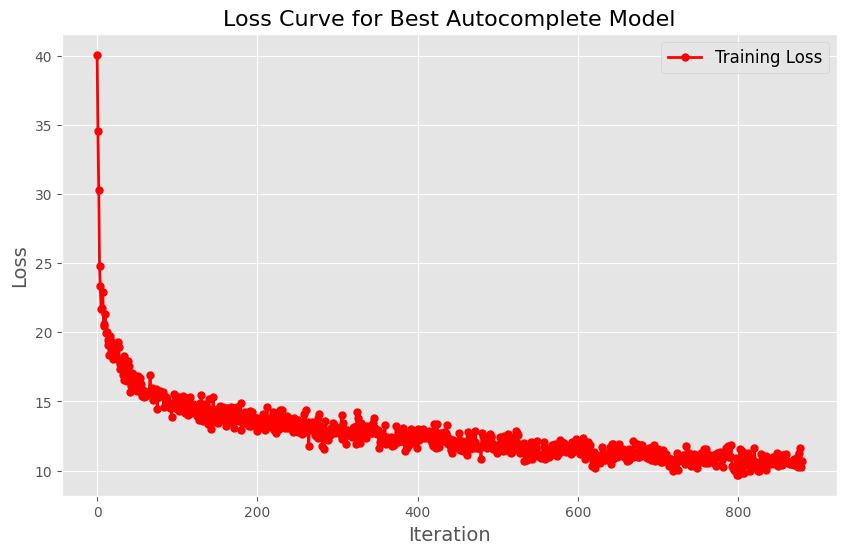

In [18]:
embedding_dims = [64]
hidden_sizes = [128]
learning_rates = [0.0005]
epochs = 10
batch_size = 100



# Store best model and loss
best_model = None
best_model_parameters={'embed_dim':0,'hidden_size':0}
lowest_loss = float('inf')

for embed_dim in embedding_dims:
    for hidden_size in hidden_sizes:
        for lr in learning_rates:
            # Initialize the model
            model = autocompleteModel(alphabet_size=27, embed_dim=embed_dim, hidden_size=hidden_size, num_layers=1)
            print(f"Training model with embed_dim={embed_dim}, hidden_size={hidden_size}, lr={lr}")

            # Set optimizer
            optimizer = optim.Adam(model.parameters(), lr=lr)

            # Train the model and return loss log
            loss_log = model.trainModel(vocab, epochs=epochs, batch_size=batch_size)

            # Calculate average loss (average of last 10 losses)
            average_loss = sum(loss_log[-10:]) / 10  # Average of the last 10 losses
            print(f"Average loss: {average_loss}")

            # Save the model checkpoint after training
            model_name = f"E:/Semester 7/MA4144 -Neural Networks and Fuzzy Logic/VS Code/assignment 3/saved_models/autocompleteModel_embed_{embed_dim}_hidden_{hidden_size}_lr_{lr}.pt"
            torch.save({
                'epoch': epochs,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'loss_log': loss_log
            }, model_name)
            print(f"Model saved as {model_name}")

            # Check if this model is the best one so far
            if average_loss < lowest_loss:
                lowest_loss = average_loss
                best_model = model
                best_model_parameters['embed_dim']=embed_dim
                best_model_parameters['hidden_size']=hidden_size
                model_name = f"saved_models/best_model.pt"
                torch.save({
                    'epoch': epochs,
                    'model_state_dict': model.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'loss_log': loss_log
                }, model_name)
                print(f"A Best Model saved")




# Use a nice built-in style (seaborn, ggplot, etc.)
plt.style.use('ggplot')

# Plot the loss curves for the best model
plt.figure(figsize=(10, 6))
plt.plot(loss_log, color='r', linewidth=2, marker='o', markersize=5)

# Add title and labels
plt.title('Loss Curve for Best Autocomplete Model', fontsize=16)
plt.xlabel('Iteration', fontsize=14)
plt.ylabel('Loss', fontsize=14)


# Add a legend if necessary
plt.legend(['Training Loss'], fontsize=12)

# Display the plot
plt.show()


In [35]:

# Load the saved model
model_name = "E:/Semester 7/MA4144 -Neural Networks and Fuzzy Logic/VS Code/assignment 3/saved_models/best_model.pt"  # Update this to match your saved model filename
checkpoint = torch.load(model_name)

# Recreate the model architecture (ensure the same parameters)
loaded_model = autocompleteModel(alphabet_size=27, embed_dim=best_model_parameters['embed_dim'], hidden_size=best_model_parameters['hidden_size'], num_layers=1)

# Load the model weights from the checkpoint
loaded_model.load_state_dict(checkpoint['model_state_dict'])

# Put the model in evaluation mode
loaded_model.eval()

# Define a list of sample inputs for autocomplete
samples = ["univ", "math", "neur", "engin"]

# Use the loaded model to predict autocompletions
outputs = loaded_model.autocomplete(samples)

# Print the results
for sample, output in zip(samples, outputs):
    print(f"Input: '{sample}' -> Output: '{output}'")

Input: 'univ' -> Output: 'univian______'
Input: 'math' -> Output: 'mathissuit___'
Input: 'neur' -> Output: 'neurefrites__'
Input: 'engin' -> Output: 'enginascace__'


C:\Users\Admin\AppData\Local\Temp\ipykernel_19440\758365753.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_name)
